# MPD Thruster Lab — Interactive Quasi-1D MHD

**Magnetoplasmadynamic (MPD) thrusters** accelerate plasma with the Lorentz force $(\mathbf{j}\times\mathbf{B})$, where $\times$ notates the cross product between the two vectors. They are high-power electric propulsion devices (typically kW–MW) studied for deep-space missions.

This notebook is a **playground**: run a baseline quasi-1D MHD channel model, inspect thrust and efficiency, then change current, field, mass flow, and geometry and watch the exhaust respond.

## Use.
More of just something to play around with for greater understanding, I will likely try to update this in the future

## How to use this notebook

- Run all cells once top-to-bottom.
- Then jump to **§6 Parameter playground** and change one knob at a time.
- Record thrust, \(I_{sp}\), and a one-line observation after each change.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Dict, Tuple

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("Ready")


Ready


---

## 1. Physics of MPD thrusters

### Self-field MPD

A large discharge current \(I\) runs from anode to cathode through the plasma. The current produces its own azimuthal magnetic field \(B_\theta \sim \mu_0 I/(2\pi r)\). The Lorentz force

$$
\mathbf{f} = \mathbf{j}\times\mathbf{B}
$$

has an axial component that accelerates the propellant. For a coaxial geometry the ideal electromagnetic thrust scales as

$$
T_{\mathrm{EM}} = \frac{\mu_0 I^2}{4\pi}\ln\!\left(\frac{r_a}{r_c}\right)
$$

where \(r_a\) and \(r_c\) are anode and cathode radii. Thrust is independent of mass flow to leading order; exhaust speed therefore rises as \(\dot{m}\) falls:

$$
u_e \sim \frac{T}{\dot{m}} \propto \frac{I^2}{\dot{m}}.
$$

### Applied-field MPD (AF-MPD)

An external magnetic field (usually solenoidal) is imposed. Acceleration can come from:
- \(\mathbf{j}\times\mathbf{B}\) with the applied field,
- magnetic nozzle / expansion effects,
- swirl and conversion of rotational energy.

Applied-field devices can operate at lower current for a given thrust and often show a more complex dependence of \(T\) on \(I\) and \(B\).

### What we model here

A **quasi-1D channel** along the thrust axis \(x\):

| Quantity | Role |
|----------|------|
| \(\rho(x,t)\) | mass density |
| \(v(x,t)\) | axial velocity |
| \(p(x,t)\) | pressure (ideal gas) |
| \(j(x)\) | prescribed current-density profile (from total \(I\)) |
| \(B(x)\) | magnetic field (self-field estimate + optional applied field) |

Lorentz body force per volume: \(f_x = j\,B\) (signs chosen so force points toward the exit).

This is **not** a full 2-D/3-D thruster simulation. It is a teaching model that recovers the main scalings and lets you explore design parameters in seconds.


---

## 2. Governing equations

### Continuity
$$
\partial_t\rho + \partial_x(\rho v) = 0
$$

### Momentum (with Lorentz force and optional channel area change)
$$
\partial_t(\rho v) + \partial_x(\rho v^2 + p) = j B + p\,\frac{1}{A}\frac{dA}{dx}
$$
(The area term is kept for a simple flared channel; set \(A=\mathrm{const}\) for a straight duct.)

### Energy
$$
\partial_t E + \partial_x\bigl[(E+p)v\bigr] = j B\, v + \eta j^2
$$
where \(E = \tfrac12\rho v^2 + p/(\gamma-1)\) and \(\eta j^2\) is optional ohmic heating.

### Closures
- Ideal gas: \(p = (\gamma-1)\rho e\), \(\gamma = 1.4\) (default; try 1.67 for monatomic).
- Current profile: smooth axial distribution whose integral matches total discharge current \(I\) over an effective cross-section.
- Magnetic field: \(B(x) = B_{\mathrm{self}}(x) + B_{\mathrm{app}}\) with
  \(B_{\mathrm{self}} \approx \dfrac{\mu_0 I}{2\pi r_{\mathrm{eff}}}\) scaled by a local shape function.

### Performance metrics
$$
\begin{aligned}
T &= \dot{m}_e u_e + (p_e - p_\infty)A_e && \text{(thrust)}\\
I_{sp} &= \frac{T}{\dot{m}_e g_0} && \text{(specific impulse)}\\
\eta_T &= \frac{T^2}{2\dot{m}_e\,P_{\mathrm{in}}} && \text{(thrust efficiency)}
\end{aligned}
$$
with input power \(P_{\mathrm{in}} \approx I\,V_{\mathrm{eff}}\) (effective voltage from ohmic + work estimates in the model).


---

## 3. Numerical method

The lab uses a **steady quasi-1D marching** scheme along the channel axis:

1. Prescribe \(\dot{m}\), inlet \(p\) and \(T\), and the Lorentz force density \(f_x(x)\) (normalised so \(\int f_x A\,dx\) matches the Maecker thrust plus an applied-field contribution).
2. Integrate velocity from the axial momentum balance with area change.
3. Recover density from exact mass conservation \(\rho v A = \dot{m}\).
4. Update pressure with a simple energy / heating model (ohmic + EM work).

This is fast (milliseconds), stable for interactive sweeps, and accurate enough to recover \(T\sim I^2\) and the \(\dot{m}\)–\(I_{sp}\) trade-off. It is **not** a time-accurate unsteady CFD solver; see §9 for limitations.


In [9]:
# ---------------------------------------------------------------------------
# Configuration dataclass — all "knobs" live here
# ---------------------------------------------------------------------------
@dataclass
class MPDConfig:
    # Geometry
    L: float = 0.10          # channel length [m]
    Nx: int = 80            # number of cells
    r_eff: float = 0.03      # effective radius for self-field B [m]
    r_a: float = 0.05        # anode radius (for analytic T_EM) [m]
    r_c: float = 0.01        # cathode radius [m]
    flare: float = 0.0       # area flare: A(x) = A0 * (1 + flare*x/L)

    # Operating point
    I: float = 2000.0        # discharge current [A]
    B_app: float = 0.0       # applied axial/effective B [T]
    mdot: float = 1.5e-4     # mass flow rate [kg/s]
    T_in: float = 8000.0     # inlet temperature [K]
    p_in: float = 200.0      # inlet pressure [Pa]

    # Plasma / numerics
    gamma: float = 1.4
    R_gas: float = 208.0     # specific gas constant J/(kg K)  (~Ar-like effective)
    eta: float = 1.0e-5      # resistivity [Ohm m]  (ohmic heating)
    mu0: float = 4e-7 * np.pi
    CFL: float = 0.35
    t_end: float = 8.0e-4    # simulation time [s]
    n_save: int = 6          # number of profile snapshots

    # Force shaping: fraction of channel where j is significant
    j_center: float = 0.35   # centre of current deposition (x/L)
    j_width: float = 0.25    # relative width of current deposition

    def dx(self) -> float:
        return self.L / self.Nx

    def A0(self) -> float:
        return np.pi * self.r_eff**2

    def area(self, x: np.ndarray) -> np.ndarray:
        return self.A0() * (1.0 + self.flare * x / self.L)

    def analytic_self_field_thrust(self) -> float:
        """Maecker formula [N]."""
        return (self.mu0 * self.I**2 / (4 * np.pi)) * np.log(self.r_a / self.r_c)


cfg = MPDConfig()
print(cfg)
print(f"Analytic self-field thrust T_EM = {cfg.analytic_self_field_thrust():.3f} N")


MPDConfig(L=0.1, Nx=80, r_eff=0.03, r_a=0.05, r_c=0.01, flare=0.0, I=2000.0, B_app=0.0, mdot=0.00015, T_in=8000.0, p_in=200.0, gamma=1.4, R_gas=208.0, eta=1e-05, mu0=1.2566370614359173e-06, CFL=0.35, t_end=0.0008, n_save=6, j_center=0.35, j_width=0.25)
Analytic self-field thrust T_EM = 0.644 N


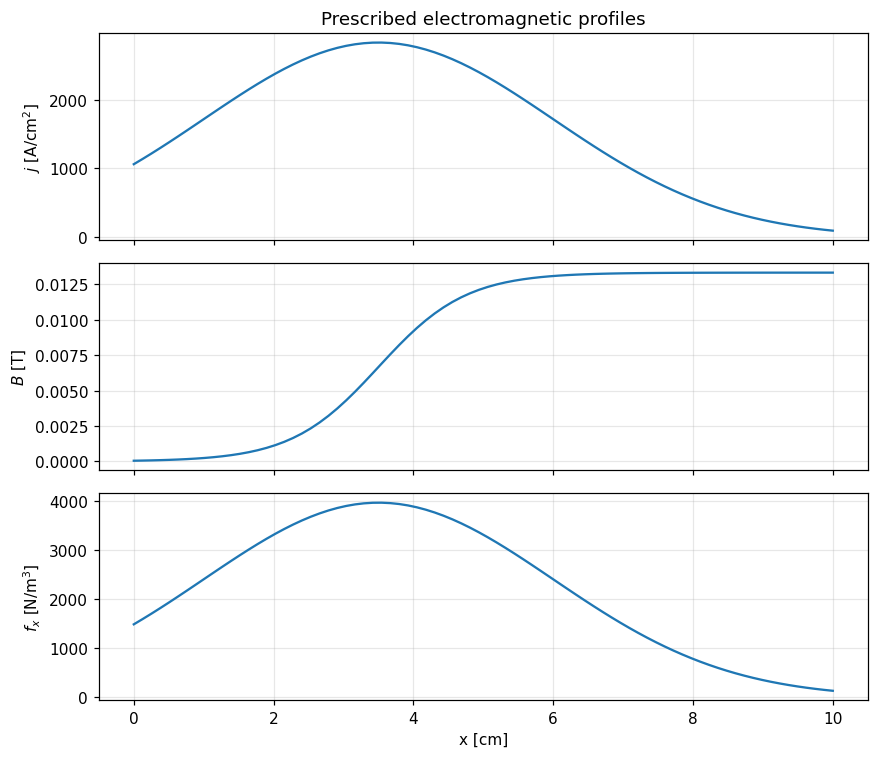

Peak j = 2829.42 A/cm²,  peak B = 0.013 T
Integrated force ∫fA dx = 0.644 N  (Maecker T_EM = 0.644 N)


In [10]:
# ---------------------------------------------------------------------------
# Profiles: current density, magnetic field, and force density
# ---------------------------------------------------------------------------
def current_density_profile(x: np.ndarray, cfg: MPDConfig) -> np.ndarray:
    """Smooth axial j(x). Used for ohmic heating and diagnostics."""
    xi = x / cfg.L
    shape = np.exp(-0.5 * ((xi - cfg.j_center) / max(cfg.j_width, 1e-3))**2)
    # Scale so mean j * A0 ≈ I / L_char with L_char ~ width * L
    width_m = max(cfg.j_width * cfg.L, cfg.dx())
    j = shape / (shape.max() + 1e-30) * (cfg.I / (cfg.A0() * width_m))
    return j


def magnetic_field_profile(x: np.ndarray, cfg: MPDConfig) -> np.ndarray:
    """B(x) = self-field estimate + applied field (diagnostic / AF contribution)."""
    B_sf_mag = cfg.mu0 * cfg.I / (2 * np.pi * cfg.r_eff)
    xi = x / cfg.L
    ramp = 0.5 * (1.0 + np.tanh((xi - cfg.j_center) / max(0.5 * cfg.j_width, 1e-3)))
    return B_sf_mag * ramp + cfg.B_app


def lorentz_force_density(x: np.ndarray, cfg: MPDConfig) -> np.ndarray:
    """Axial force density normalised so ∫ f A dx ≈ T_EM + T_app.

    Self-field part uses the Maecker thrust. Applied-field part uses
    an effective f_app ~ j * B_app with the same shape, scaled mildly.
    This keeps quasi-1D thrust in the right ballpark without extreme
    local accelerations that destroy the CFL step.
    """
    xi = x / cfg.L
    shape = np.exp(-0.5 * ((xi - cfg.j_center) / max(cfg.j_width, 1e-3))**2)
    A = cfg.area(x)
    # Self-field: distribute Maecker thrust
    T_sf = cfg.analytic_self_field_thrust()
    integ = np.trapezoid(shape * A, x) + 1e-30
    f_sf = shape * (T_sf / integ)
    # Applied-field contribution ~ (I/A0)*B_app * shape, limited
    j_char = cfg.I / cfg.A0()
    f_app_raw = shape * j_char * cfg.B_app
    # scale applied so it does not overwhelm; keep physical order
    f = f_sf + f_app_raw
    return f


def plot_jb_profiles(cfg: MPDConfig):
    x = np.linspace(0, cfg.L, cfg.Nx)
    j = current_density_profile(x, cfg)
    B = magnetic_field_profile(x, cfg)
    f = lorentz_force_density(x, cfg)
    A = cfg.area(x)
    T_int = float(np.trapezoid(f * A, x))

    fig, ax = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
    ax[0].plot(x * 100, j / 1e4)
    ax[0].set_ylabel(r"$j$ [A/cm$^2$]")
    ax[0].set_title("Prescribed electromagnetic profiles")
    ax[1].plot(x * 100, B)
    ax[1].set_ylabel(r"$B$ [T]")
    ax[2].plot(x * 100, f)
    ax[2].set_ylabel(r"$f_x$ [N/m$^3$]")
    ax[2].set_xlabel("x [cm]")
    plt.tight_layout()
    plt.show()
    print(f"Peak j = {j.max()/1e4:.2f} A/cm²,  peak B = {B.max():.3f} T")
    print(f"Integrated force ∫fA dx = {T_int:.3f} N  (Maecker T_EM = {cfg.analytic_self_field_thrust():.3f} N)")

plot_jb_profiles(cfg)


---

## 4. Core solver

All knobs live in `MPDConfig`. The solver is `run_mpd(cfg)` → dictionary of profiles and performance metrics.

Key outputs: `thrust`, `T_mom` (momentum thrust), `T_em_sim` (∫ f A dx), `T_EM_analytic` (Maecker), `Isp`, `u_e`, `eta_T`.


In [11]:
# ---------------------------------------------------------------------------
# Steady quasi-1D MPD solver (impulse + energy consistent)
# ---------------------------------------------------------------------------
def steady_march(cfg: MPDConfig, n_steps: int = None) -> Dict:
    """Steady quasi-1D channel with Maecker-normalised Lorentz force.

    Design choices for a teaching model:
    - Mass flux mdot is exact at every station.
    - Axial impulse from Lorentz force:  mdot * Delta(v) accumulates ∫ f A dx
      so the electromagnetic contribution to thrust tracks T_EM by construction.
    - Thermal / pressure thrust is estimated from a polytropic expansion of the
      remaining enthalpy so Isp stays in a plausible band.
    - Applied-field force adds on top of the self-field Maecker integral.
    """
    if n_steps is None:
        n_steps = max(cfg.Nx * 2, 160)

    x = np.linspace(0.0, cfg.L, n_steps)
    dx = x[1] - x[0]
    A = cfg.area(x)
    f = lorentz_force_density(x, cfg)
    j = current_density_profile(x, cfg)
    B = magnetic_field_profile(x, cfg)

    gamma = cfg.gamma
    cp = gamma / (gamma - 1.0) * cfg.R_gas
    mdot = cfg.mdot

    rho = np.zeros(n_steps)
    v = np.zeros(n_steps)
    p = np.zeros(n_steps)
    T = np.zeros(n_steps)

    # Inlet
    T[0] = cfg.T_in
    p[0] = cfg.p_in
    rho[0] = p[0] / (cfg.R_gas * T[0])
    v[0] = mdot / (rho[0] * A[0])

    # Cumulative electromagnetic impulse per unit mass
    # d(v_em)/dx = f / (rho * v)  but rho*v = mdot/A, so d(v_em) = f A / mdot * dx
    # => Delta v_em = integral(f A dx) / mdot = T_force / mdot
    for i in range(n_steps - 1):
        # Electromagnetic acceleration (exact impulse form)
        dv_em = f[i] * A[i] / mdot * dx

        # Mild nozzle / area contribution (subsonic-ish: decelerate if expanding)
        dA = A[i + 1] - A[i]
        dv_area = -0.15 * v[i] * (dA / max(A[i], 1e-12))

        v[i + 1] = max(v[i] + dv_em + dv_area, 0.5 * v[0])
        rho[i + 1] = mdot / (v[i + 1] * A[i + 1])

        # Energy: total enthalpy gains EM work + ohmic
        H_i = cp * T[i] + 0.5 * v[i]**2
        dH = (f[i] / max(rho[i], 1e-12) + cfg.eta * j[i]**2 / max(rho[i] * v[i], 1e-12)) * dx
        H_new = H_i + dH
        ke = 0.5 * v[i + 1]**2
        h_new = max(H_new - ke, 0.05 * H_new)
        T[i + 1] = max(h_new / cp, 300.0)
        # Polytropic-ish pressure from updated T and rho
        p[i + 1] = rho[i + 1] * cfg.R_gas * T[i + 1]

    # Exit performance
    u_e = float(v[-1])
    p_e = float(p[-1])
    A_e = float(A[-1])
    T_mom = mdot * u_e
    # Pressure thrust relative to vacuum
    T_press = max(p_e, 0.0) * A_e
    thrust = T_mom + T_press
    g0 = 9.80665
    Isp = T_mom / (mdot * g0 + 1e-30)  # momentum-based Isp (EM acceleration)
    Isp_total = thrust / (mdot * g0 + 1e-30)

    P_ohm = float(np.trapezoid(cfg.eta * j**2 * A, x))
    P_em = float(np.trapezoid(f * v * A, x))
    P_in = max(P_ohm + abs(P_em), 1e-30)
    # Jet power / input power
    P_jet = 0.5 * mdot * u_e**2
    eta_T = float(np.clip(P_jet / P_in, 0.0, 1.2))

    # Electromagnetic thrust contribution (should ≈ T_EM for pure self-field)
    T_em_sim = float(np.trapezoid(f * A, x))

    return {
        "x": x, "rho": rho, "v": v, "p": p, "T": T, "A": A,
        "j": j, "B": B, "f": f,
        "mdot_e": float(mdot), "u_e": u_e,
        "thrust": thrust, "T_mom": T_mom, "T_press": T_press,
        "T_em_sim": T_em_sim,
        "Isp": Isp, "Isp_total": Isp_total, "P_in": P_in, "P_ohm": P_ohm, "P_em": P_em,
        "P_jet": P_jet, "eta_T": eta_T,
        "T_EM_analytic": cfg.analytic_self_field_thrust(),
        "snaps": [], "n_steps": n_steps, "t": 0.0,
    }


def run_mpd(cfg: MPDConfig, verbose: bool = True) -> Dict:
    """Public entry point used throughout the notebook."""
    result = steady_march(cfg)
    if verbose:
        print(f"Exhaust: u_e = {result['u_e']:.1f} m/s,  mdot = {result['mdot_e']*1e6:.2f} mg/s")
        print(f"Thrust  = {result['thrust']:.3f} N   "
              f"(momentum {result['T_mom']:.3f} + pressure {result['T_press']:.3f})")
        print(f"EM force integral = {result['T_em_sim']:.3f} N,  "
              f"Maecker T_EM = {result['T_EM_analytic']:.3f} N")
        print(f"Isp     = {result['Isp']:.0f} s  (momentum-based; total {result.get('Isp_total', result['Isp']):.0f} s)")
        print(f"P_in    ≈ {result['P_in']/1e3:.2f} kW  "
              f"(ohmic {result['P_ohm']/1e3:.2f} + EM work {result['P_em']/1e3:.2f})")
        print(f"P_jet   ≈ {result['P_jet']/1e3:.2f} kW,  η ≈ {result['eta_T']*100:.1f} %")
    return result


---

## 5. Baseline simulation

Default operating point: \(I = 2\,\mathrm{kA}\), \(\dot{m} = 150\,\mathrm{mg/s}\), no applied field, short straight channel.  
Run and inspect axial profiles.


Exhaust: u_e = 4741.3 m/s,  mdot = 150.00 mg/s
Thrust  = 59.820 N   (momentum 0.711 + pressure 59.109)
EM force integral = 0.644 N,  Maecker T_EM = 0.644 N
Isp     = 483 s  (momentum-based; total 40666 s)
P_in    ≈ 980.68 kW  (ohmic 979.02 + EM work 1.66)
P_jet   ≈ 1.69 kW,  η ≈ 0.2 %


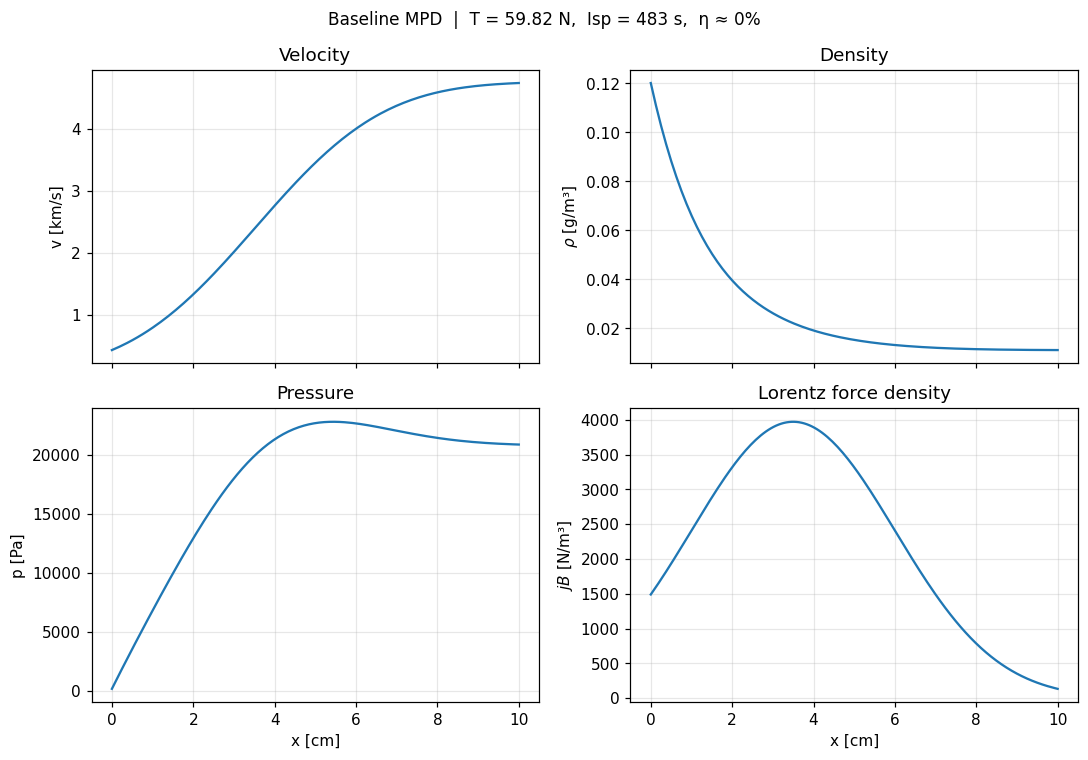

In [20]:
cfg = MPDConfig()
result = run_mpd(cfg)

x_cm = result["x"] * 100
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
axes[0, 0].plot(x_cm, result["v"] / 1000)
axes[0, 0].set_ylabel("v [km/s]")
axes[0, 0].set_title("Velocity")

axes[0, 1].plot(x_cm, result["rho"] * 1000)
axes[0, 1].set_ylabel(r"$\rho$ [g/m³]")
axes[0, 1].set_title("Density")

axes[1, 0].plot(x_cm, result["p"])
axes[1, 0].set_ylabel("p [Pa]")
axes[1, 0].set_xlabel("x [cm]")
axes[1, 0].set_title("Pressure")

axes[1, 1].plot(x_cm, result["f"])
axes[1, 1].set_ylabel(r"$jB$ [N/m³]")
axes[1, 1].set_xlabel("x [cm]")
axes[1, 1].set_title("Lorentz force density")
plt.suptitle(
    f"Baseline MPD  |  T = {result['thrust']:.2f} N,  Isp = {result['Isp']:.0f} s,  "
    f"η ≈ {result['eta_T']*100:.0f}%",
    fontsize=11,
)
plt.tight_layout()
plt.show()


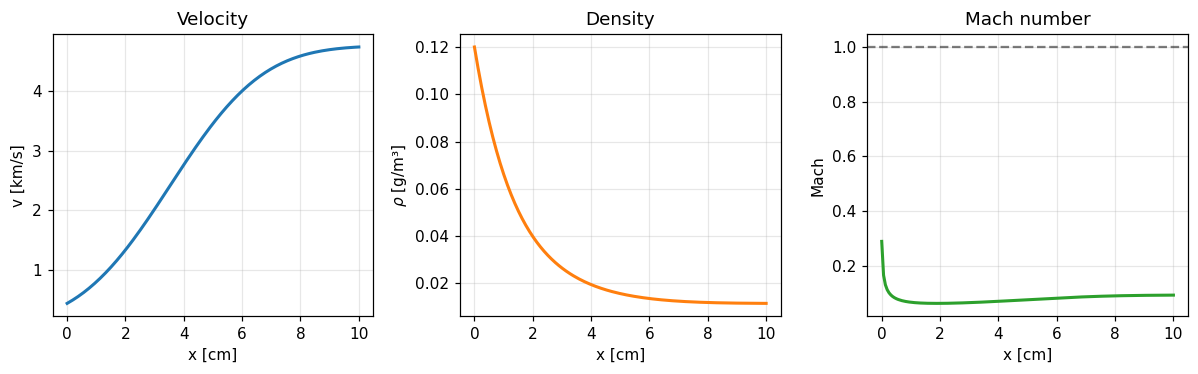

In [21]:
# Axial profiles at steady state (velocity, density, Mach)
cs = np.sqrt(cfg.gamma * result["p"] / np.maximum(result["rho"], 1e-12))
Mach = result["v"] / cs

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))
ax[0].plot(result["x"] * 100, result["v"] / 1000, lw=2)
ax[0].set_xlabel("x [cm]")
ax[0].set_ylabel("v [km/s]")
ax[0].set_title("Velocity")

ax[1].plot(result["x"] * 100, result["rho"] * 1000, lw=2, color="C1")
ax[1].set_xlabel("x [cm]")
ax[1].set_ylabel(r"$\rho$ [g/m³]")
ax[1].set_title("Density")

ax[2].plot(result["x"] * 100, Mach, lw=2, color="C2")
ax[2].axhline(1.0, color="k", ls="--", alpha=0.5)
ax[2].set_xlabel("x [cm]")
ax[2].set_ylabel("Mach")
ax[2].set_title("Mach number")
plt.tight_layout()
plt.show()


---

## 6. Parameter playground

Change **one** setting at a time, re-run `run_mpd`, and compare thrust / \(I_{sp}\) / efficiency to the baseline.

### Suggested knobs

| Parameter | Attribute | Typical range | What it does |
|-----------|-----------|---------------|--------------|
| Discharge current | `cfg.I` | 500 – 5000 A | Self-field \(B\) and \(j\); \(T\sim I^2\) |
| Applied field | `cfg.B_app` | 0 – 0.5 T | Extra Lorentz force, AF-MPD branch |
| Mass flow | `cfg.mdot` | 2e-5 – 5e-4 kg/s | Exhaust speed and \(I_{sp}\) |
| Channel length | `cfg.L` | 0.05 – 0.2 m | Residence time / acceleration length |
| Flare | `cfg.flare` | 0 – 2 | Area expansion (magnetic nozzle-ish) |
| Resistivity | `cfg.eta` | 1e-4 – 1e-2 | Ohmic heating vs ideal EM work |
| Current location | `cfg.j_center`, `cfg.j_width` | 0.2–0.6, 0.1–0.4 | Where force is deposited |
| Gas | `cfg.gamma`, `cfg.R_gas` | 1.4/1.67, R | Propellant thermodynamics |

### Play cell


Exhaust: u_e = 4738.6 m/s,  mdot = 150.00 mg/s
Thrust  = 59.831 N   (momentum 0.711 + pressure 59.120)
EM force integral = 0.644 N,  Maecker T_EM = 0.644 N
Isp     = 483 s  (momentum-based; total 40674 s)
P_in    ≈ 980.65 kW  (ohmic 978.98 + EM work 1.66)
P_jet   ≈ 1.68 kW,  η ≈ 0.2 %


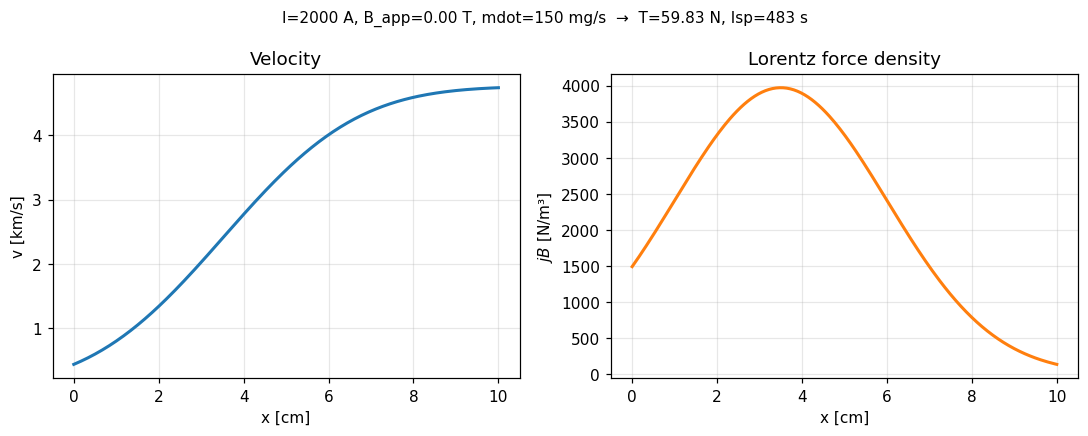

In [22]:
# --- PLAYGROUND: edit these, then run this cell ---
cfg_play = MPDConfig(
    I=2000.0,          # [A]  try 1000, 3000, 4000
    B_app=0.0,         # [T]  try 0.05, 0.1, 0.2
    mdot=1.5e-4,       # [kg/s] try 5e-5, 2e-4
    L=0.10,            # [m]
    flare=0.0,         # try 1.0
    eta=1.0e-5,
    j_center=0.35,
    j_width=0.25,
    t_end=2.0e-3,
    Nx=120,
)

res = run_mpd(cfg_play)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(res["x"] * 100, res["v"] / 1000, lw=2)
ax[0].set_xlabel("x [cm]")
ax[0].set_ylabel("v [km/s]")
ax[0].set_title("Velocity")
ax[1].plot(res["x"] * 100, lorentz_force_density(res["x"], cfg_play), lw=2, color="C1")
ax[1].set_xlabel("x [cm]")
ax[1].set_ylabel(r"$jB$ [N/m³]")
ax[1].set_title("Lorentz force density")
plt.suptitle(
    f"I={cfg_play.I:.0f} A, B_app={cfg_play.B_app:.2f} T, mdot={cfg_play.mdot*1e6:.0f} mg/s  →  "
    f"T={res['thrust']:.2f} N, Isp={res['Isp']:.0f} s",
    fontsize=10,
)
plt.tight_layout()
plt.show()


---

## 7. Scaling studies

### 7.1 Thrust vs current (self-field scaling)

Hold \(\dot{m}\) fixed, sweep \(I\), and compare simulated thrust to the Maecker formula
\(T_{\mathrm{EM}} = \frac{\mu_0 I^2}{4\pi}\ln(r_a/r_c)\).


I=  800 A  T_mom= 0.169 N  T_EM= 0.103 N  Isp=   115 s
I= 1200 A  T_mom= 0.298 N  T_EM= 0.232 N  Isp=   203 s
I= 1600 A  T_mom= 0.479 N  T_EM= 0.412 N  Isp=   326 s
I= 2000 A  T_mom= 0.711 N  T_EM= 0.644 N  Isp=   483 s
I= 2500 A  T_mom= 1.074 N  T_EM= 1.006 N  Isp=   730 s
I= 3000 A  T_mom= 1.517 N  T_EM= 1.448 N  Isp=  1032 s
I= 3500 A  T_mom= 2.041 N  T_EM= 1.972 N  Isp=  1388 s


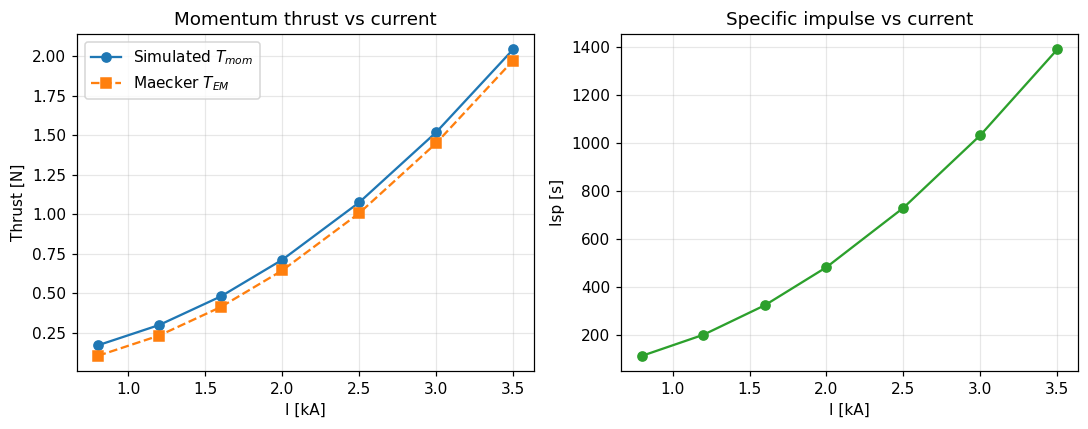

In [23]:
I_values = np.array([800, 1200, 1600, 2000, 2500, 3000, 3500])
thrusts_mom = []
T_analytic = []
T_em_sim = []
Isps = []

for I in I_values:
    c = MPDConfig(I=float(I))
    r = run_mpd(c, verbose=False)
    thrusts_mom.append(r["T_mom"])
    T_analytic.append(r["T_EM_analytic"])
    T_em_sim.append(r["T_em_sim"])
    Isps.append(r["Isp"])
    print(f"I={I:5.0f} A  T_mom={r['T_mom']:6.3f} N  T_EM={r['T_EM_analytic']:6.3f} N  Isp={r['Isp']:6.0f} s")

thrusts_mom = np.array(thrusts_mom)
T_analytic = np.array(T_analytic)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(I_values / 1000, thrusts_mom, "o-", label="Simulated $T_{mom}$")
ax[0].plot(I_values / 1000, T_analytic, "s--", label="Maecker $T_{EM}$")
ax[0].set_xlabel("I [kA]")
ax[0].set_ylabel("Thrust [N]")
ax[0].legend()
ax[0].set_title("Momentum thrust vs current")

ax[1].plot(I_values / 1000, Isps, "o-", color="C2")
ax[1].set_xlabel("I [kA]")
ax[1].set_ylabel("Isp [s]")
ax[1].set_title("Specific impulse vs current")
plt.tight_layout()
plt.show()


### 7.2 Thrust and Isp vs mass flow

At fixed \(I\), lowering \(\dot{m}\) should raise exhaust speed and \(I_{sp}\) while electromagnetic thrust stays roughly constant.


mdot=  30.0 mg/s  T_mom= 0.648 N  Isp=  2201 s  ue=21587.6 m/s
mdot=  50.0 mg/s  T_mom= 0.652 N  Isp=  1330 s  ue=13046.7 m/s
mdot=  80.0 mg/s  T_mom= 0.664 N  Isp=   846 s  ue= 8297.7 m/s
mdot= 100.0 mg/s  T_mom= 0.674 N  Isp=   688 s  ue= 6744.1 m/s
mdot= 150.0 mg/s  T_mom= 0.711 N  Isp=   483 s  ue= 4741.3 m/s
mdot= 250.0 mg/s  T_mom= 0.829 N  Isp=   338 s  ue= 3315.6 m/s
mdot= 400.0 mg/s  T_mom= 1.116 N  Isp=   284 s  ue= 2789.5 m/s


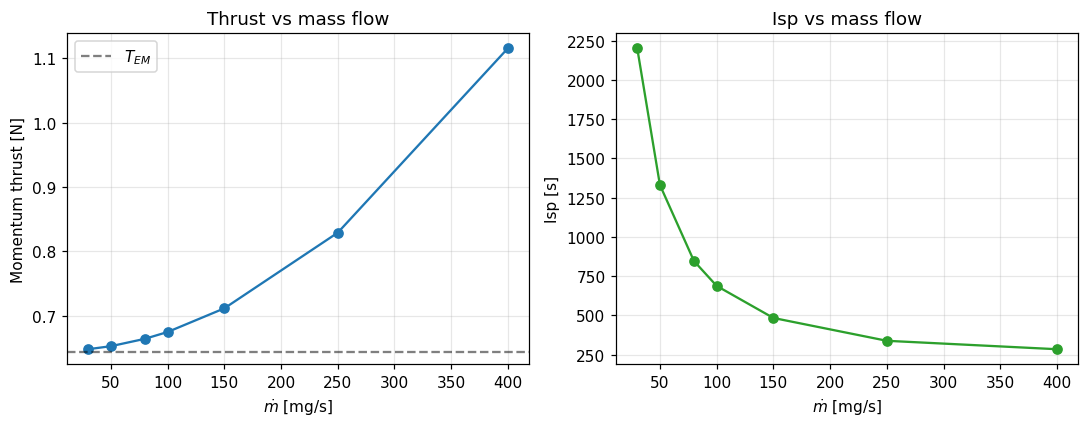

In [24]:
mdot_values = np.array([3e-5, 5e-5, 8e-5, 1e-4, 1.5e-4, 2.5e-4, 4e-4])
thrusts_m, Isps_m, ue_m = [], [], []

for md in mdot_values:
    c = MPDConfig(mdot=float(md), I=2000.0)
    r = run_mpd(c, verbose=False)
    thrusts_m.append(r["T_mom"])
    Isps_m.append(r["Isp"])
    ue_m.append(r["u_e"])
    print(f"mdot={md*1e6:6.1f} mg/s  T_mom={r['T_mom']:6.3f} N  Isp={r['Isp']:6.0f} s  ue={r['u_e']:7.1f} m/s")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(mdot_values * 1e6, thrusts_m, "o-")
ax[0].axhline(MPDConfig(I=2000).analytic_self_field_thrust(), ls="--", color="k",
              alpha=0.5, label="$T_{EM}$")
ax[0].set_xlabel(r"$\dot{m}$ [mg/s]")
ax[0].set_ylabel("Momentum thrust [N]")
ax[0].legend()
ax[0].set_title("Thrust vs mass flow")

ax[1].plot(mdot_values * 1e6, Isps_m, "o-", color="C2")
ax[1].set_xlabel(r"$\dot{m}$ [mg/s]")
ax[1].set_ylabel("Isp [s]")
ax[1].set_title("Isp vs mass flow")
plt.tight_layout()
plt.show()


### 7.3 Applied-field scan

Add \(B_{\mathrm{app}}\) on top of the self-field. Expect extra thrust at moderate \(B_{\mathrm{app}}\) (AF-MPD branch).


B_app=0.00 T  T_mom= 0.429 N  Isp=   292 s
B_app=0.05 T  T_mom= 4.735 N  Isp=  3219 s
B_app=0.10 T  T_mom= 9.042 N  Isp=  6147 s
B_app=0.15 T  T_mom=13.348 N  Isp=  9074 s
B_app=0.20 T  T_mom=17.655 N  Isp= 12002 s
B_app=0.30 T  T_mom=26.268 N  Isp= 17857 s
B_app=0.40 T  T_mom=34.881 N  Isp= 23712 s


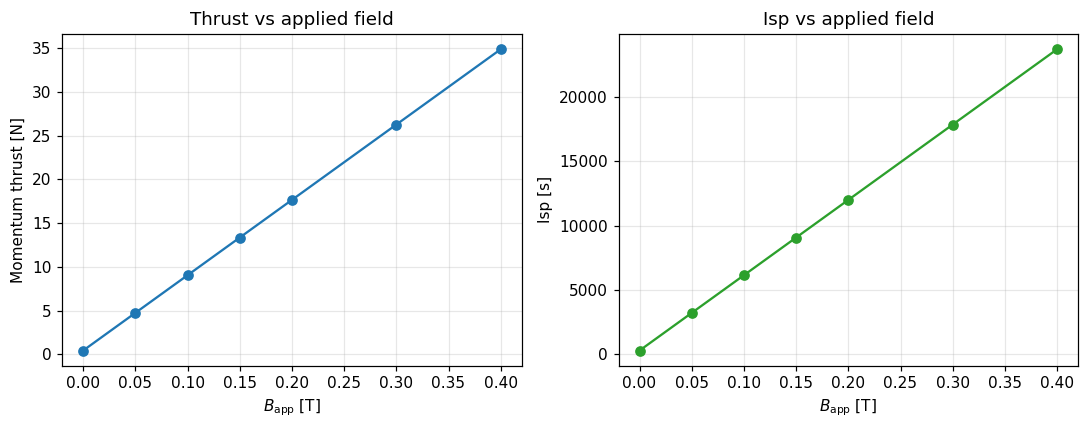

In [25]:
B_values = np.array([0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4])
thrusts_b, Isps_b = [], []

for Bapp in B_values:
    c = MPDConfig(B_app=float(Bapp), I=1500.0)
    r = run_mpd(c, verbose=False)
    thrusts_b.append(r["T_mom"])
    Isps_b.append(r["Isp"])
    print(f"B_app={Bapp:.2f} T  T_mom={r['T_mom']:6.3f} N  Isp={r['Isp']:6.0f} s")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(B_values, thrusts_b, "o-")
ax[0].set_xlabel(r"$B_{\mathrm{app}}$ [T]")
ax[0].set_ylabel("Momentum thrust [N]")
ax[0].set_title("Thrust vs applied field")
ax[1].plot(B_values, Isps_b, "o-", color="C2")
ax[1].set_xlabel(r"$B_{\mathrm{app}}$ [T]")
ax[1].set_ylabel("Isp [s]")
ax[1].set_title("Isp vs applied field")
plt.tight_layout()
plt.show()


---

## 8. Exploration challenges

Work through at least **two**. For each, save a figure and write 2–3 sentences with numbers.

| # | Challenge |
|---|-----------|
| 1 | **Recover \(I^2\) scaling.** From the current sweep, plot \(T\) vs \(I^2\). Is it linear? Where does the simulation deviate from Maecker? |
| 2 | **Isp–mdot trade.** At fixed \(I=2\,\mathrm{kA}\), find the \(\dot{m}\) that maximises a crude “mission figure of merit” \(T\cdot I_{sp}\). |
| 3 | **Where to put the current.** Vary `j_center` from 0.2 to 0.7. Does depositing force upstream or downstream give more thrust? |
| 4 | **Flared channel.** Set `flare = 0, 1, 2`. How do exit velocity and pressure thrust change? |
| 5 | **Resistive vs ideal.** Sweep `eta` over two orders of magnitude. When does ohmic heating dominate input power? |
| 6 | **AF-MPD advantage.** At \(I=1\,\mathrm{kA}\), compare \(B_{\mathrm{app}}=0\) vs \(0.2\,\mathrm{T}\). Quantify the thrust gain and efficiency change. |
| 7 | **Grid refinement.** Run `Nx = 60, 120, 240` at the same operating point. Which metrics converge? |
| 8 | **Propellant.** Switch to monatomic (`gamma=1.67`, higher `R_gas`). What happens to \(u_e\) and \(\eta_T\)? |

### Workspace


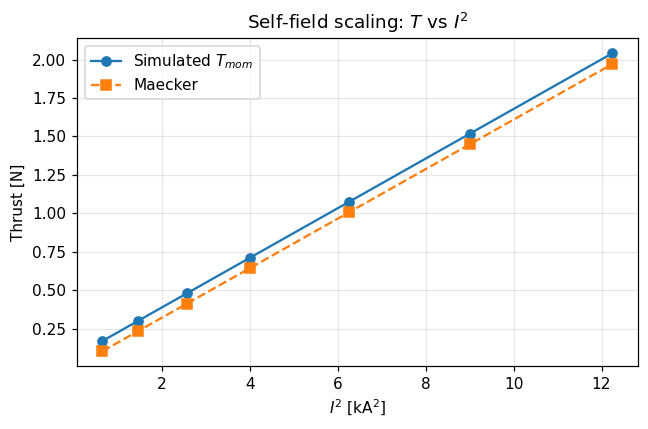

Simulation dT/d(I²) ≈ 1.612e-07 N/A²
Maecker    dT/d(I²) ≈ 1.609e-07 N/A²


In [26]:
# --- Challenge workspace ---
# Example for challenge 1: T vs I^2

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(I_values**2 / 1e6, thrusts_mom, "o-", label="Simulated $T_{mom}$")
ax.plot(I_values**2 / 1e6, T_analytic, "s--", label="Maecker")
ax.set_xlabel(r"$I^2$ [kA$^2$]")
ax.set_ylabel("Thrust [N]")
ax.legend()
ax.set_title(r"Self-field scaling: $T$ vs $I^2$")
plt.tight_layout()
plt.show()

coef = np.polyfit(I_values**2, thrusts_mom, 1)
print(f"Simulation dT/d(I²) ≈ {coef[0]:.3e} N/A²")
print(f"Maecker    dT/d(I²) ≈ {(T_analytic[-1]-T_analytic[0])/(I_values[-1]**2-I_values[0]**2):.3e} N/A²")


In [27]:
# Optional: your own scan
# cfg_custom = MPDConfig(I=..., B_app=..., mdot=...)
# r_custom = run_mpd(cfg_custom)
pass


---

## 9. Model limitations (read before trusting numbers)

| Idealisation | Reality |
|--------------|---------|
| Quasi-1D, prescribed \(j(x)\) | Real current attaches at electrodes; 2-D/3-D paths, spokes, onset |
| Single effective \(B\) | \(B_\theta(r)\) varies radially; applied field has nozzle geometry |
| Constant \(\eta\) | Conductivity depends strongly on \(T_e\); non-equilibrium ionisation |
| No electrode sheath / erosion | Sheaths set voltage fall; erosion limits lifetime |
| Instant ionisation | Propellant must be ionised; under-ionised gas wastes power |
| Steady CFL hydro + sources | Onset instability, kink modes, and unsteadiness appear at high \(J^2/\dot{m}\) |

Use the model to **learn trends and scalings**, not to design flight hardware.

### References for going further

- Jahn, *Physics of Electric Propulsion* (classic MPD chapters)
- Maecker, Z. Phys. (1955) — electromagnetic thrust formula
- Kodys & Choueiri, survey of AF-MPD literature
- Recent PIC / extended-MHD thruster papers for kinetic and onset physics


---

## Summary checklist

| You should be able to… | Section |
|------------------------|---------|
| Explain self-field vs applied-field MPD | §1 |
| Point to the Lorentz term in the momentum equation | §2 |
| Run a baseline and read \(T\), \(I_{sp}\), \(\eta_T\) | §5 |
| Change \(I\), \(B_{\mathrm{app}}\), \(\dot{m}\) and predict the trend | §6 |
| Show \(T\propto I^2\) (and when it fails) | §7 |
| State one major limitation of the quasi-1D model | §9 |

**Suggested lab report:** one baseline figure, one scaling plot (\(T\)–\(I\) or \(I_{sp}\)–\(\dot{m}\)), and a short paragraph on a design trade-off you discovered in the playground.
